# Validación de normalización de atributos

Este notebook verifica min/max de columnas numéricas en nodos y aristas.
Marca como `fuera_de_rango=True` cualquier columna que no esté en [0,1].

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Ajusta estas rutas si cambian tus archivos
base = Path('/media/vale/KINGSTON/TESIS/data_2026')
nodes_file = base / 'nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'
edges_file = base / 'edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv'

print(f'nodes_file: {nodes_file}')
print(f'edges_file: {edges_file}')
print('nodes existe:', nodes_file.exists())
print('edges existe:', edges_file.exists())

nodes_file: /media/vale/KINGSTON/TESIS/data_2026/nodes_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv
edges_file: /media/vale/KINGSTON/TESIS/data_2026/edges_rib_20260301_0000_to_20260302_0000_enriched_tesis.csv
nodes existe: True
edges existe: True


In [2]:
nodes_df = pd.read_csv(nodes_file)
edges_df = pd.read_csv(edges_file)

print('Nodos shape:', nodes_df.shape)
print('Aristas shape:', edges_df.shape)
print('\nColumnas nodos:', len(nodes_df.columns))
print('Columnas aristas:', len(edges_df.columns))

Nodos shape: (79504, 74)
Aristas shape: (734381, 6)

Columnas nodos: 74
Columnas aristas: 6


In [3]:
def resumen_numerico(df, nombre, excluir=None):
    excluir = set(excluir or [])
    num_cols = [c for c in df.columns if c not in excluir and pd.api.types.is_numeric_dtype(df[c])]
    rows = []
    for c in num_cols:
        s = pd.to_numeric(df[c], errors='coerce')
        mn = float(s.min(skipna=True)) if s.notna().any() else np.nan
        mx = float(s.max(skipna=True)) if s.notna().any() else np.nan
        rows.append({
            'columna': c,
            'min': mn,
            'max': mx,
            'nulos_%': float(s.isna().mean() * 100),
            'unicos': int(s.nunique(dropna=True)),
            'fuera_de_rango': bool((mn < 0) or (mx > 1)) if pd.notna(mn) and pd.notna(mx) else False
        })
    out = pd.DataFrame(rows).sort_values(['fuera_de_rango', 'columna'], ascending=[False, True])
    print(f'\n=== Resumen numérico: {nombre} ===')
    display(out)
    return out

# Excluir IDs/etiquetas que no tienen que estar en [0,1]
excluir_nodos = {'node_id', 'asn'}
excluir_aristas = {'src_id', 'dst_id', 'src_asn', 'dst_asn', 'relationship'}

res_nodes = resumen_numerico(nodes_df, 'NODOS', excluir_nodos)
res_edges = resumen_numerico(edges_df, 'ARISTAS', excluir_aristas)


=== Resumen numérico: NODOS ===


,columna,min,max,nulos_%,unicos,fuera_de_rango
4,PageRank,0.0,1.0,0.0,65361,False
2,betweenness_centrality,0.0,1.0,0.0,7787,False
1,degree_centrality,0.0,1.0,0.0,473,False
3,eigenvector_centrality,0.0,1.0,0.0,67788,False
6,fac_count,0.0,1.0,0.0,108,False
...,...,...,...,...,...,...
16,policy_locations_Required - EU,0.0,1.0,0.0,2,False
17,policy_locations_Required - International,0.0,1.0,0.0,2,False
18,policy_locations_Required - US,0.0,1.0,0.0,2,False
19,policy_locations_Unknown,0.0,1.0,0.0,2,False



=== Resumen numérico: ARISTAS ===


,columna,min,max,nulos_%,unicos,fuera_de_rango
0,weight,0.0,1.0,0.0,5580,False


In [4]:
# Columnas fuera de [0,1]
bad_nodes = res_nodes[res_nodes['fuera_de_rango']]
bad_edges = res_edges[res_edges['fuera_de_rango']]

print('Columnas de NODOS fuera de [0,1]:', len(bad_nodes))
display(bad_nodes[['columna', 'min', 'max']])

print('Columnas de ARISTAS fuera de [0,1]:', len(bad_edges))
display(bad_edges[['columna', 'min', 'max']])

Columnas de NODOS fuera de [0,1]: 0


,columna,min,max


Columnas de ARISTAS fuera de [0,1]: 0


,columna,min,max


In [5]:
# (Opcional) Exportar reportes
out_dir = Path('./results/normalizacion')
out_dir.mkdir(parents=True, exist_ok=True)

res_nodes.to_csv(out_dir / 'reporte_normalizacion_nodos.csv', index=False)
res_edges.to_csv(out_dir / 'reporte_normalizacion_aristas.csv', index=False)

print('Reportes guardados en:', out_dir.resolve())

Reportes guardados en: /home/vale/Escritorio/GIT/TrabajoTesis/notebooks/results/normalizacion


## Attribute Visualizations by Relationship Type

Distributions of **node** and **edge** features split by relationship type (P2P / C2P / P2C).

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

REL_MAP    = {0: 'P2P', 1: 'C2P', 2: 'P2C', -1: 'Unknown'}
REL_ORDER  = ['P2P', 'C2P', 'P2C']
REL_COLORS = {'P2P': '#2196F3', 'C2P': '#FF9800', 'P2C': '#4CAF50'}

### Edge Attributes by Relationship Type

Edges per relationship type:
  P2P: 340,512
  C2P: 159,963
  P2C: 159,963


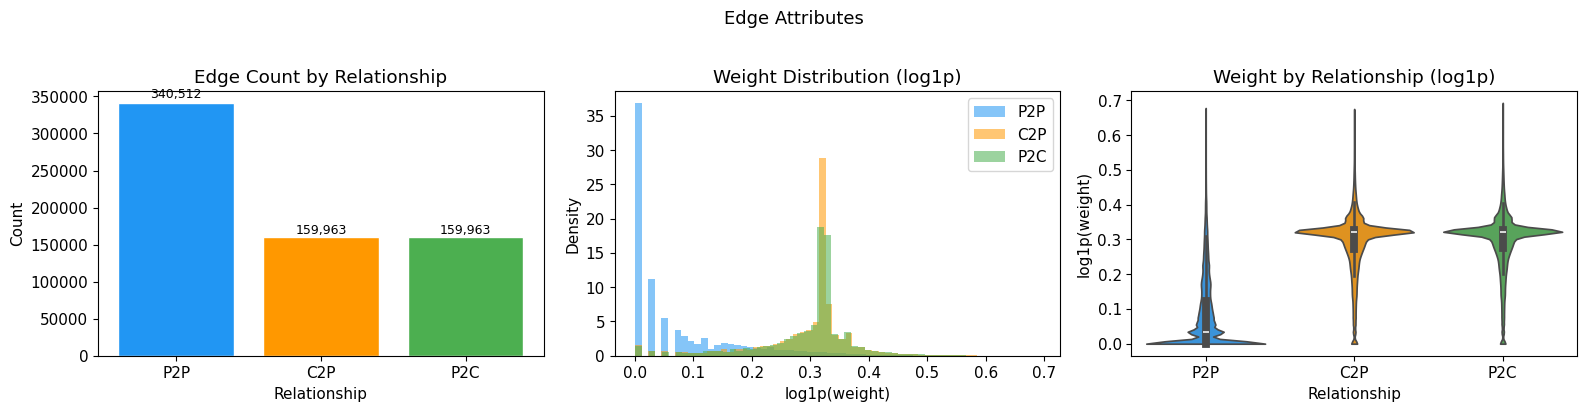

In [7]:
edges_labeled = edges_df[edges_df['relationship'].isin([0, 1, 2])].copy()
edges_labeled['rel_name'] = edges_labeled['relationship'].map(REL_MAP)
edges_labeled['log_weight'] = np.log1p(edges_labeled['weight'])

counts = edges_labeled['rel_name'].value_counts()
print("Edges per relationship type:")
for r in REL_ORDER:
    print(f"  {r}: {counts.get(r, 0):,}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# --- Edge count by type ---
ax = axes[0]
vals = [counts.get(r, 0) for r in REL_ORDER]
bars = ax.bar(REL_ORDER, vals, color=[REL_COLORS[r] for r in REL_ORDER], edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f'{v:,}', ha='center', va='bottom', fontsize=9)
ax.set_title('Edge Count by Relationship')
ax.set_xlabel('Relationship')
ax.set_ylabel('Count')

# --- Weight histogram (log1p scale) ---
ax = axes[1]
for rel in REL_ORDER:
    subset = edges_labeled[edges_labeled['rel_name'] == rel]['log_weight']
    ax.hist(subset, bins=60, alpha=0.55, label=rel, color=REL_COLORS[rel], density=True)
ax.set_title('Weight Distribution (log1p)')
ax.set_xlabel('log1p(weight)')
ax.set_ylabel('Density')
ax.legend()

# --- Violin plot of log1p(weight) by relationship ---
ax = axes[2]
sns.violinplot(
    data=edges_labeled, x='rel_name', y='log_weight',
    order=REL_ORDER, palette=REL_COLORS, ax=ax,
    inner='box', cut=0
)
ax.set_title('Weight by Relationship (log1p)')
ax.set_xlabel('Relationship')
ax.set_ylabel('log1p(weight)')

plt.suptitle('Edge Attributes', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Node Attributes by Dominant Relationship Type

Each node is assigned the most frequent relationship type among its outgoing edges.

In [8]:
# Assign dominant relationship to each node based on its outgoing edges
node_rel_counts = (
    edges_labeled
    .groupby(['src_id', 'rel_name'])
    .size()
    .reset_index(name='count')
)
dominant_rel = (
    node_rel_counts
    .loc[node_rel_counts.groupby('src_id')['count'].idxmax()]
    [['src_id', 'rel_name']]
    .rename(columns={'src_id': 'node_id', 'rel_name': 'dominant_rel'})
)

nodes_with_rel = nodes_df.merge(dominant_rel, on='node_id', how='inner')

print(f"Nodes with assigned relationship: {len(nodes_with_rel):,} / {len(nodes_df):,}")
print("\nNode count by dominant relationship:")
print(nodes_with_rel['dominant_rel'].value_counts().to_string())

Nodes with assigned relationship: 78,921 / 79,504

Node count by dominant relationship:
dominant_rel
C2P    66463
P2P     9125
P2C     3333


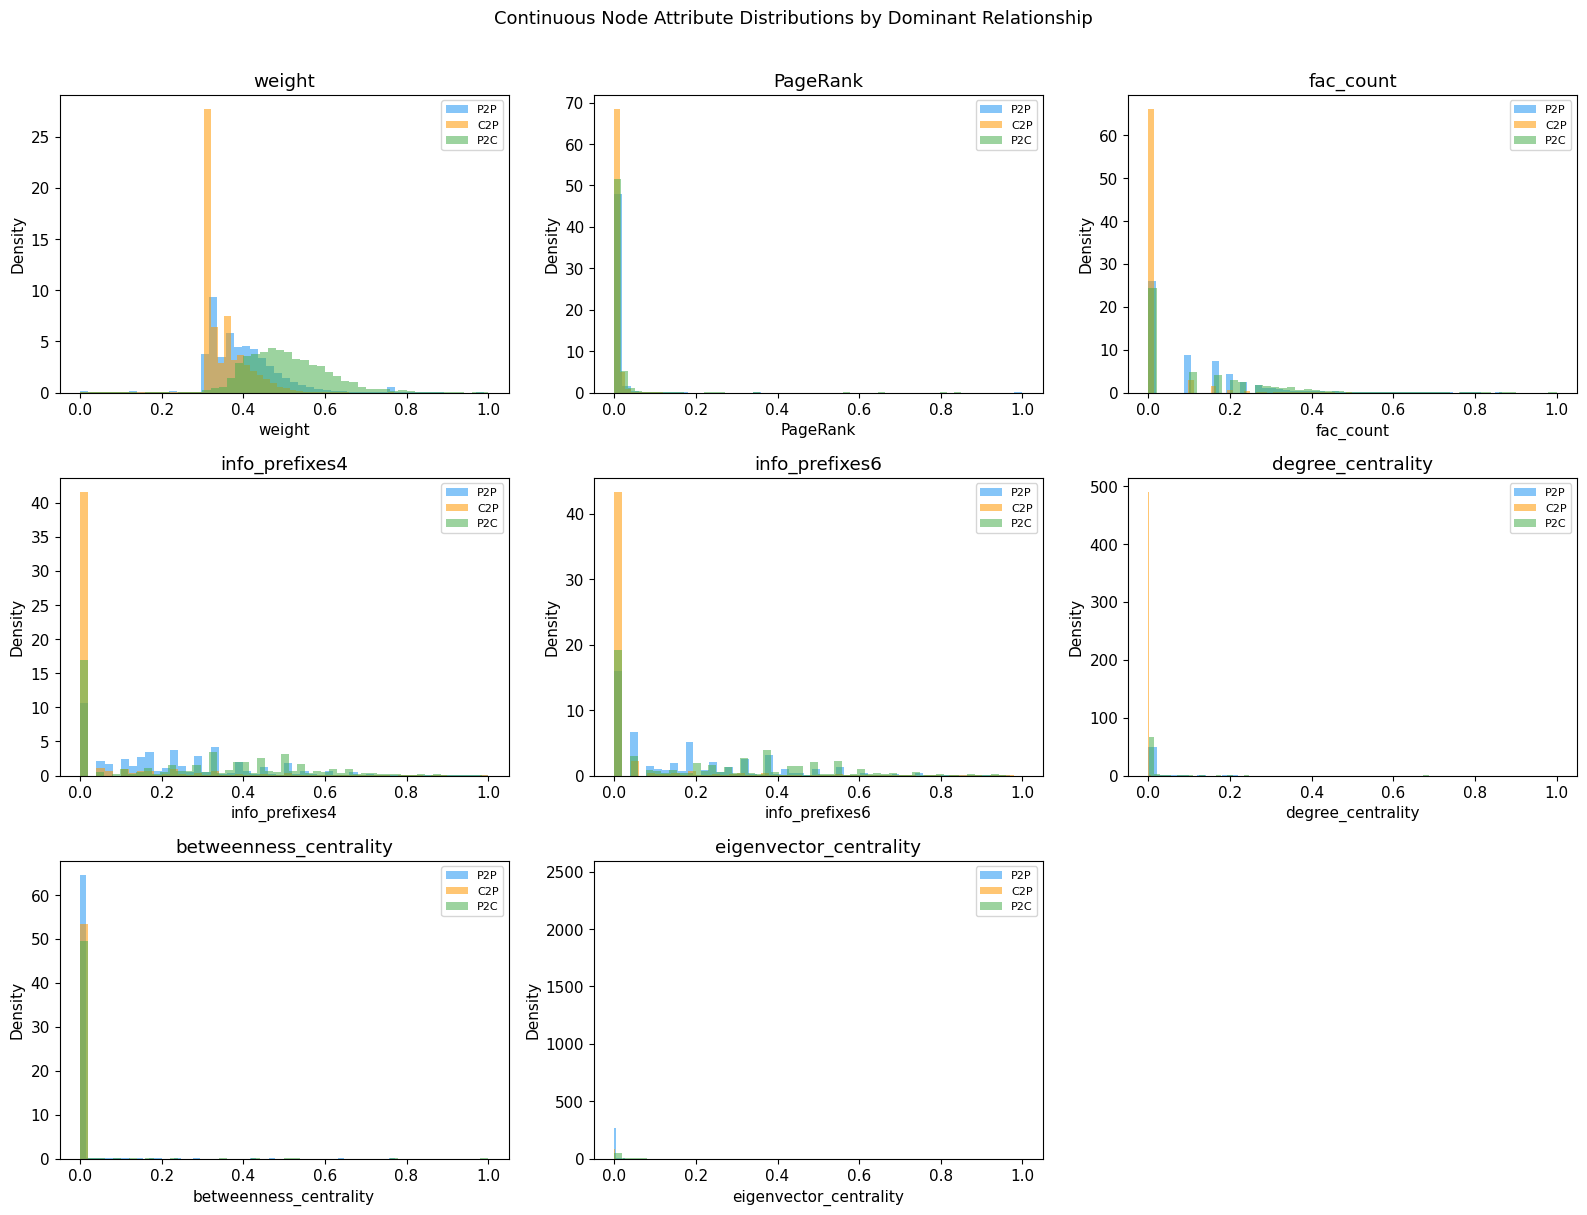

In [9]:
# Continuous features to visualize (includes centrality columns if present)
CANDIDATE_FEATS = [
    'weight', 'PageRank', 'fac_count', 'info_prefixes4', 'info_prefixes6',
    'degree_centrality', 'betweenness_centrality', 'eigenvector_centrality',
]
FEAT_COLS = [c for c in CANDIDATE_FEATS if c in nodes_with_rel.columns]
rels_present = [r for r in REL_ORDER if r in nodes_with_rel['dominant_rel'].unique()]

n_cols = 3
n_rows = max(1, (len(FEAT_COLS) + n_cols - 1) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(FEAT_COLS):
    ax = axes[i]
    col_max = nodes_with_rel[col].max(skipna=True)
    use_log = col_max > 1      # apply log1p for columns outside [0, 1]
    for rel in rels_present:
        subset = nodes_with_rel[nodes_with_rel['dominant_rel'] == rel][col].dropna()
        vals = np.log1p(subset) if use_log else subset
        ax.hist(vals, bins=50, alpha=0.55, label=rel, color=REL_COLORS[rel], density=True)
    ax.set_title(col)
    ax.set_xlabel(f'log1p({col})' if use_log else col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

for j in range(len(FEAT_COLS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Continuous Node Attribute Distributions by Dominant Relationship',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [10]:
# Median of continuous node attributes by relationship type
summary = nodes_with_rel.groupby('dominant_rel')[FEAT_COLS].median().loc[rels_present]

print("Median of continuous node attributes by dominant relationship:")
display(summary.style
        .background_gradient(cmap='Blues', axis=0)
        .format('{:.5f}'))

Median of continuous node attributes by dominant relationship:


,weight,PageRank,fac_count,info_prefixes4,info_prefixes6,degree_centrality,betweenness_centrality,eigenvector_centrality
dominant_rel,,,,,,,,
P2P,0.38562,0.00046,0.10335,0.19602,0.12908,0.00220,0.00000,0.00005
C2P,0.32448,0.00052,0.00000,0.00000,0.00000,0.00010,0.00000,0.00001
P2C,0.49457,0.00214,0.10335,0.28459,0.19232,0.00136,0.00020,0.00026


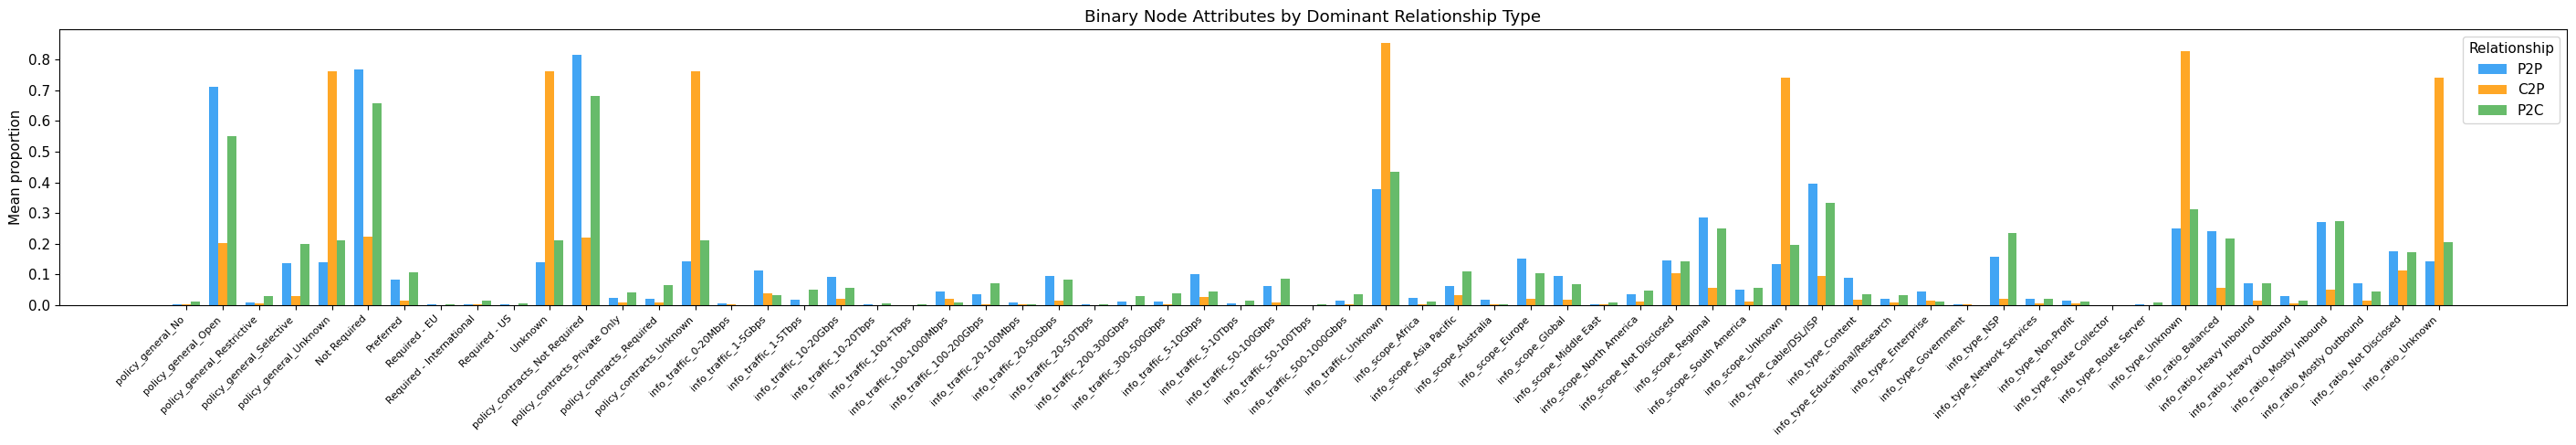

In [11]:
# Binary node attributes (policy_locations, etc.) — mean proportion per relationship
bin_cols = [
    c for c in nodes_df.columns
    if c not in excluir_nodos
    and c not in FEAT_COLS
    and pd.api.types.is_numeric_dtype(nodes_df[c])
    and set(nodes_df[c].dropna().unique()).issubset({0, 1, 0.0, 1.0})
    and nodes_df[c].nunique(dropna=True) == 2
]

if bin_cols:
    mean_by_rel = (
        nodes_with_rel.groupby('dominant_rel')[bin_cols]
        .mean()
        .loc[rels_present]
    )
    fig, ax = plt.subplots(figsize=(max(14, len(bin_cols) * 0.45), 5))
    x = np.arange(len(bin_cols))
    width = 0.25
    for k, rel in enumerate(rels_present):
        ax.bar(x + k * width, mean_by_rel.loc[rel], width,
               label=rel, color=REL_COLORS[rel], alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(
        [c.replace('policy_locations_', '') for c in bin_cols],
        rotation=45, ha='right', fontsize=8
    )
    ax.set_ylabel('Mean proportion')
    ax.set_title('Binary Node Attributes by Dominant Relationship Type')
    ax.legend(title='Relationship')
    plt.tight_layout()
    plt.show()
else:
    print("No additional binary columns found to visualize.")